In [2]:
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from skimage import transform
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3201s 19us/step


In [4]:
print("Training data shape:", x_train.shape, y_train.shape)
print("Testing data shape:", x_test.shape, y_test.shape)

Training data shape: (50000, 32, 32, 3) (50000, 1)
Testing data shape: (10000, 32, 32, 3) (10000, 1)


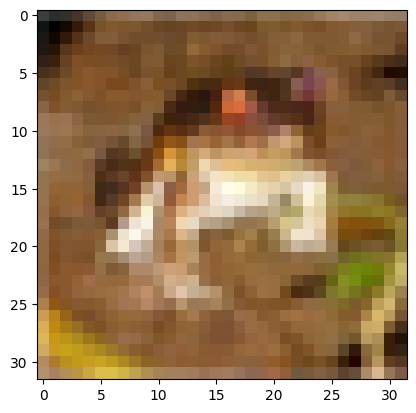

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
The label of the first training image: [6]


In [5]:
img = plt.imshow(x_train[0])
plt.show()

print(x_train[0]) # Display the first training image
print("The label of the first training image:", y_train[0]) # Display the label of the first training image

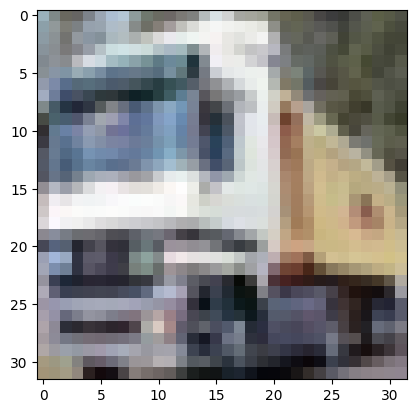

[[[154 177 187]
  [126 137 136]
  [105 104  95]
  ...
  [ 91  95  71]
  [ 87  90  71]
  [ 79  81  70]]

 [[140 160 169]
  [145 153 154]
  [125 125 118]
  ...
  [ 96  99  78]
  [ 77  80  62]
  [ 71  73  61]]

 [[140 155 164]
  [139 146 149]
  [115 115 112]
  ...
  [ 79  82  64]
  [ 68  70  55]
  [ 67  69  55]]

 ...

 [[175 167 166]
  [156 154 160]
  [154 160 170]
  ...
  [ 42  34  36]
  [ 61  53  57]
  [ 93  83  91]]

 [[165 154 128]
  [156 152 130]
  [159 161 142]
  ...
  [103  93  96]
  [123 114 120]
  [131 121 131]]

 [[163 148 120]
  [158 148 122]
  [163 156 133]
  ...
  [143 133 139]
  [143 134 142]
  [143 133 144]]]
The label of the second training image: [9]


In [6]:
img = plt.imshow(x_train[1])
plt.show()

print(x_train[1]) # Display the second training image
print("The label of the second training image:", y_train[1]) # Display the label of the second training image

In [7]:
y_train_one_hot = to_categorical(y_train, 10)
y_test_one_hot = to_categorical(y_test, 10)

print("The one-hot encoded label of the second training image:", y_train_one_hot[1]) # Display the one-hot encoded label of the second training image

The one-hot encoded label of the second training image: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [8]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train[0]

array([[[0.23137255, 0.24313726, 0.24705882],
        [0.16862746, 0.18039216, 0.1764706 ],
        [0.19607843, 0.1882353 , 0.16862746],
        ...,
        [0.61960787, 0.5176471 , 0.42352942],
        [0.59607846, 0.49019608, 0.4       ],
        [0.5803922 , 0.4862745 , 0.40392157]],

       [[0.0627451 , 0.07843138, 0.07843138],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509805, 0.21568628],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117648, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215687, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941177, 0.19607843],
        [0.47058824, 0.32941177, 0.19607843],
        [0.42745098, 0.28627452, 0.16470589]],

       ...,

       [[0.8156863 , 0.6666667 , 0.3764706 ],
        [0.7882353 , 0.6       , 0.13333334],
        [0.7764706 , 0

In [9]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same', input_shape = (32, 32, 3)))
model.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), activation = 'relu', padding = 'same'))
model.add(Conv2D(64, (3, 3), activation = 'relu', padding = 'same'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation = 'softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,362 (8.27 MB)

 Trainable params: 2,168,362 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [12]:
hist = model.fit(x_train, y_train_one_hot, batch_size = 32, epochs = 20, validation_split = 0.2)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 241s 190ms/step - accuracy: 0.4309 - loss: 1.5528 - val_accuracy: 0.5654 - val_loss: 1.2061
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 230s 184ms/step - accuracy: 0.5903 - loss: 1.1499 - val_accuracy: 0.6514 - val_loss: 0.9814
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 260s 183ms/step - accuracy: 0.6524 - loss: 0.9816 - val_accuracy: 0.6960 - val_loss: 0.8835
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 261s 182ms/step - accuracy: 0.6888 - loss: 0.8792 - val_accuracy: 0.7070 - val_loss: 0.8300
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 262s 182ms/step - accuracy: 0.7210 - loss: 0.7974 - val_accuracy: 0.7446 - val_loss: 0.7345
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 231s 184ms/step - accuracy: 0.7390 - loss: 0.7418 - val_accuracy: 0.7327 - val_loss: 0.7695
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 229s 183ms/step - accuracy: 0.7560 - loss: 0.6916 - val_accuracy: 0.7646 - val_loss: 0.6825
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 234s 187ms/step - ac

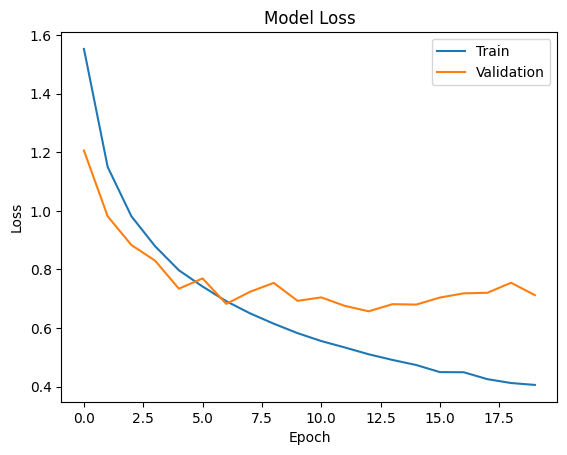

In [13]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper right')
plt.show()

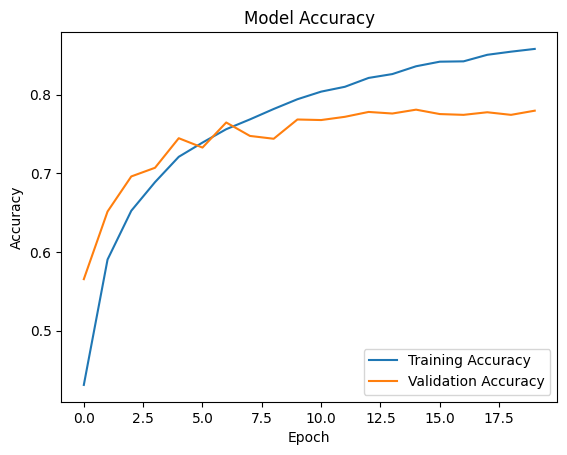

In [14]:
plt.plot(hist.history['accuracy'], label = 'Training Accuracy')
plt.plot(hist.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc = 'lower right')
plt.show()

In [15]:
model.evaluate(x_test, y_test_one_hot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.7713 - loss: 0.7403


[0.7403096556663513, 0.7713000178337097]

In [16]:
model.save('cifar10_cnn_model.h5')

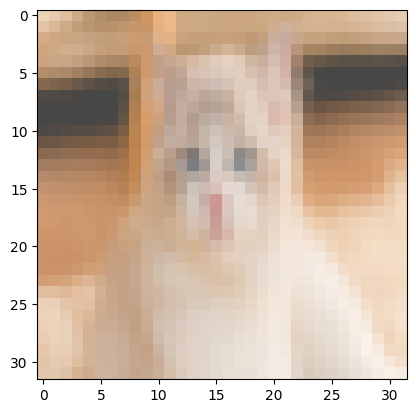

In [17]:
cat_image = plt.imread('/content/cat.jpg')
cat_image_resized = transform.resize(cat_image, (32, 32, 3))
img = plt.imshow(cat_image_resized)
plt.show()

In [18]:
probabilities = model.predict(np.array([cat_image_resized, ]))

number_to_class = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog',
'horse', 'ship', 'truck']
index = np.argsort(probabilities[0,:])
print("Most likely class:", number_to_class[index[9]], "-- Probability:",
probabilities[0,index[9]])
print("Second most likely class:", number_to_class[index[8]], "-- Probability:",
probabilities[0,index[8]])
print("Third most likely class:", number_to_class[index[7]], "-- Probability:",
probabilities[0,index[7]])
print("Fourth most likely class:", number_to_class[index[6]], "-- Probability:",
probabilities[0,index[6]])
print("Fifth most likely class:", number_to_class[index[5]], "-- Probability:",
probabilities[0,index[5]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Most likely class: dog -- Probability: 0.72375864
Second most likely class: cat -- Probability: 0.2745706
Third most likely class: bird -- Probability: 0.0009123875
Fourth most likely class: deer -- Probability: 0.00044386563
Fifth most likely class: horse -- Probability: 0.00018662855
